In [82]:
import pandas as pd
import statsmodels.formula.api as smf

## The insulate Case Study

The insulate database contains data about fuel consumption to
heat a certain building. Assume (a big assumption!) that
we have two random samples of weeks, before (26 weeks) and after (30 weeks)
some insulating work was done on the building:
in these days we recorded:

* quando: an indicator for before/after
* Temp = average weekly external temperature in Celsius 
* Cons: fuel consuption (in ft^3). 

We want to study a linear model explaining Cons as a function
of quando and Temp.

### 1. Exploratory Data Analysis.

Before modeling, we treat our data as points in a Hilbert Space H. We are looking for the "shape" of the manifold.

#### 1.1. Setup and Loading.

Define the variables. 
- $y∈R^{56}$ (Consumption), 
- $x_1​ ∈ {0,1}$ (Dummy variable for quando), 
- $x_2​ ∈ R$ (Temperature).

We are working with '.txt' data.
- it doesn't have any headers.
- the features are separated by whitespaces.

We can use the 'sep' , 'names' & 'header' parameters of 'read_csv' which will allow us to process the dataset as intended.

In [100]:
df1 = pd.read_csv("260401 insulate data.txt", sep=r"\s+", header=None, names=["quando", "temp", "cons"])

In [101]:
df1.info()
print(f"Dataset Shape: {df1.shape}")

<class 'pandas.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   quando  56 non-null     str    
 1   temp    56 non-null     float64
 2   cons    56 non-null     float64
dtypes: float64(2), str(1)
memory usage: 1.4 KB
Dataset Shape: (56, 3)


In [102]:
print("Categorical Levels:", df1['quando'].unique())

Categorical Levels: <StringArray>
['prima', 'dopo']
Length: 2, dtype: str


In [103]:
df1.describe()

,temp,cons
count,56.000000,56.000000
mean,4.875000,4.071429
std,2.749562,1.167860
min,-0.800000,1.300000
25%,3.050000,3.500000
50%,4.900000,3.950000
75%,7.125000,4.625000
max,10.200000,7.200000


#### 1.2. Descriptive Statistics & Visual Geometry.

The connection between Linear Models and the Multivariate Normal (MVN) is profound: if the vector $[x,y]^T$ follows a Multivariate Normal distribution, then the conditional distribution $y∣x$ is guaranteed to be a Normal distribution with a mean that is a linear function of $x$.

For our dataset, we are looking for evidence that:
- **Marginal Normality**: Each variable (at least the continuous ones, temp and cons) looks Gaussian.
- **Joint Ellipticity**: In a scatter plot, the points should form an "elliptical cloud." This is a visual signature of a bivariate normal distribution.

##### The "Conditioning" Proof:
To say $y$ is conditioned on $x$, we are essentially stating that $E[y∣x]=f(x)$. If $f(x)$ is a line, we have a *linear model*. If the distribution of $y$ shifts or changes shape when $x$ changes, $y$ is conditioned on $x$.

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

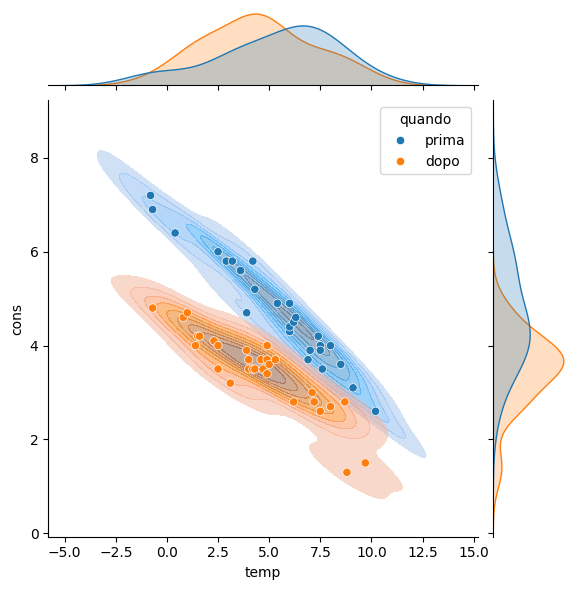

In [105]:
# When you use kind='kde', you are visualizing the Joint Probability Density Function (PDF), f(x,y).

grid = sns.jointplot(x='temp', y='cons', data=df1, kind='kde', hue='quando', fill=True, alpha=0.5)
grid.plot_joint(sns.scatterplot)
plt.show()

**Visual Interpretation**: Think of this as a "topographical map." The contours represent lines of equal probability density.

**Mathematical Proof**: A key property of the Multivariate Normal distribution is that its "level sets" (isodensity contours) are ellipses.
- Since the kde plot shows concentric ellipses, you have visual evidence that the joint distribution is Bivariate Normal.
- The orientation of the ellipse shows the Correlation ($ρ$). A tilted ellipse means $x$ and $y$ are dependent.

**Conditioning**: By looking at a vertical slice of the KDE, you are seeing the shape of the conditional distribution $p(y∣x)$. In a Bivariate Normal, this slice should look like a 1D Gaussian.

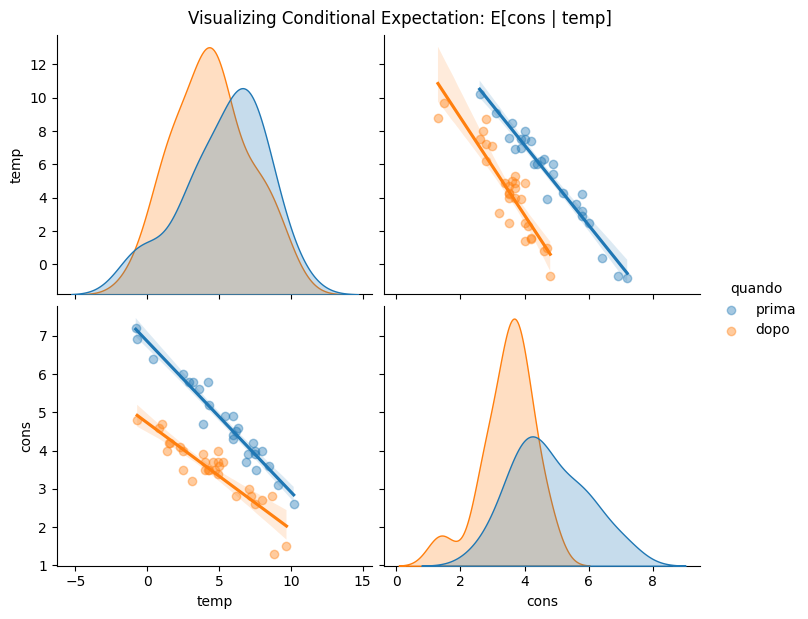

In [106]:
# Visualizing the Functional Relationship
#'reg' fits a linear regression line (LSE) and shows marginal KDEs
# We use pairplot to see relationships across all numeric variables
# but we focus on 'temp' vs 'cons'
pp = sns.pairplot(df1, 
                  hue='quando', 
                  kind='reg', 
                  height=3, 
                  aspect=1.2,
                  plot_kws={'scatter_kws': {'alpha': 0.4}})

pp.fig.suptitle("Visualizing Conditional Expectation: E[cons | temp]", y=1.02)
plt.show()

When you use kind='reg', you are shifting the focus from the "cloud of density" to the Conditional Expectation, $E[y∣x]$.

**Visual Interpretation**: You see the raw points (the noise) and a "best-fit" line.

**Mathematical Proof**: This visualizes the regression identity: $E[y∣x]=μ_y​+ ρ \frac{σ_x​}{σy}​​(x−μ_x​)$.

- Instead of looking at the shape of the whole distribution, you are looking at the trend of the mean.

- The shaded area around the line (the confidence band) represents the uncertainty in our estimate of that mean.

**Conditioning**: This proves y is conditioned on x by showing that as x increases, the average value of y predictably changes.

In [107]:
# 2. Numerical Evidence: Correlation Matrix
# This represents the standardized covariance matrix Sigma
print("Correlation Matrix:")
print(df1[['temp', 'cons']].corr())

Correlation Matrix:
          temp      cons
temp  1.000000 -0.683254
cons -0.683254  1.000000


**Theory Note**: In a Multivariate Normal $N(μ,Σ)$, the off-diagonal elements of the covariance matrix $Σ$ define the relationship. 

**Mathematical Interpretation**: A correlation of −0.683 is quite high. It means that approximately 46.6% ($r^2$) of the variance in fuel consumption can be explained by temperature alone, without even considering the insulation yet.

**The Negative Sign**: Geometrically, the major axis of your "probability ellipse" is sloping downwards. This proves that y is conditioned on x: as x (Temp) moves away from its mean, the conditional distribution $p(y∣x)$ shifts its mean downward.

**Geometric Insight**: If $r$ were 0, the joint density contours would be circles (assuming equal variance). Since $r≈−0.7$, we have clear elliptical contours, which is a visual signature of a non-degenerate Multivariate Normal distribution.

We can also run the **Shapiro-Wilk** test on the target variable $y$ ("cons"). This is the "stress test" for our marginal normality assumption. If the p-value is high, our Multivariate Normal assumption is stronger. 

The Logic of the Test:

- $H_0$​: The data is distributed normally.

- $H_1$​: The data is NOT distributed normally.

In [91]:
from scipy.stats import shapiro
stat, p = shapiro(df1['cons'])
print(f"Shapiro-Wilk Test for 'cons': p-value = {p:.4f}")
# If p > 0.05, we fail to reject the null hypothesis of normality.

Shapiro-Wilk Test for 'cons': p-value = 0.0784


**The Result**: The p-value (0.0784) is greater than the standard significance level (α=0.05).

**The Conclusion**: We fail to reject $H_0$​. We can proceed under the assumption that fuel consumption follows a normal distribution.

### 2. The Additive Model (Parallel Manifolds).
Now that we've proven the data "lives" in a well-behaved geometric space (MVN-like) and that a strong linear relationship exists, we are ready to perform the Projection.

We are going to perform **Least Squares Estimation (LSE)**. Mathematically, we are projecting $y$ onto the subspace spanned by the columns of our design matrix $X$.


#### 2.1. Understanding Ordinary Least Squares in Statsmodels

To understand what `smf.ols()` actually does, you have to look at it as a three-stage machine. It takes a "human-readable" string and converts it into a rigid "mathematical-executable" linear algebra problem.


---

##### Stage 1: The Parser (Patsy)
When you pass `'cons ~ quando + temp'`, `statsmodels` hands that string over to a library called **Patsy**. This is the stage where a "Categorical Trick" happens.

* **LHS (Left Hand Side):** It isolates `cons` as the dependent variable vector $y$.
* **RHS (Right Hand Side):** It looks at `quando` and `temp`. 
    * It sees `temp` is numerical, so it keeps it as a column of numbers.
    * It sees `quando` is a string (`prima`/`dopo`), so it creates a **Dummy Variable** ($1$ or $0$).
    * It automatically adds a column of **1s** (the **Intercept**).

**The Result:** A matrix $X$ (the Design Matrix) and a vector $y$.


---

##### Stage 2: The Solver (Linear Algebra)
Now that it has matrices $X$ and $y$, it needs to find the "best" vector of coefficients $\beta = [\beta_0, \beta_1, \beta_2]^T$. 

The "OLS" in the name stands for **Ordinary Least Squares**. Mathematically, it is looking for the $\beta$ that minimizes the **Residual Sum of Squares (RSS)**:
$$RSS(\beta) = \sum_{i=1}^n (y_i - X_i\beta)^2 = \|y - X\beta\|^2$$

**The Normal Equations:**
To find the minimum, it solves the "Normal Equations":
$$(X^T X)\beta = X^T y$$
If the matrix $(X^T X)$ is invertible (meaning your columns aren't redundant, i.e., "Full Rank"), the solution is:
$$\hat{\beta} = (X^T X)^{-1} X^T y$$


---

##### Stage 3: The Statistician (Inference)
The `.fit()` method doesn't just calculate $\hat{\beta}$. It also calculates the "health" of those estimates. This is the part that occupies $90\%$ of the `summary()` table.

1.  **Standard Errors:** It calculates how much $\hat{\beta}$ would vary if we had different samples. This depends on the variance of the residuals ($\hat{\sigma}^2$).
2.  **t-statistics:** It divides the coefficient by its standard error ($t = \frac{\hat{\beta}}{SE(\hat{\beta})}$).
3.  **p-values:** It checks the probability of seeing a $t$-score that high if the "true" coefficient was actually zero.
4.  **Projection:** It calculates the "Fitted Values" $\hat{y} = X\hat{\beta}$. These are the points on the regression line.

---

##### Why use `smf.ols` instead of `np.linalg.lstsq`?
You *could* solve for $\beta$ using pure NumPy linear algebra, but you would have to:
1.  Manually create the column of 1s.
2.  Manually encode the "prima/dopo" strings.
3.  Manually calculate the $p$-values and $R^2$.

`smf.ols()` is essentially a **wrapper** that automates the transition from **Data Science (Strings/DataFrames)** to **Mathematics (Matrices)** to **Statistics (Summaries)**.


In [92]:
# Mathematically: cons = beta_0 + beta_1*I(quando=prima) + beta_2*temp + epsilon
regr = smf.ols('cons ~ quando + temp', data=df1).fit()

In [93]:
# Print the full statistical summary
print(regr.summary())

                            OLS Regression Results                            
Dep. Variable:                   cons   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     267.1
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           2.09e-28
Time:                        18:13:03   Log-Likelihood:                -20.302
No. Observations:                  56   AIC:                             46.60
Df Residuals:                      53   BIC:                             52.68
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           4.9861      0.103     

#### 2.2. Interpreting the OLS Regression Results.

This table is the "Medical Report" of your model. It tells you if the model is healthy, if the variables are actually doing anything, and if you can trust the results.

##### Zone 1: The Model Metadata
This section tells you about the "Global" performance of the projection.

| Statistic | Mathematical Meaning | Interpretation in Insulate Study | Results 
| :--- | :--- | :--- | :--- |
| **R-squared** | $1 - \frac{RSS}{TSS}$ | The percentage of variance explained. Usually $>0.8$ is excellent. | 0.910
| **Adj. R-squared** | Penalizes adding "junk" variables. | Useful for comparing models with different numbers of predictors. | 0.906
| **F-statistic** | Tests $H_0: \beta_1 = \beta_2 = \dots = 0$ | Does the model explain *anything* better than just a flat line? | 267.1
| **Prob (F-stat)** | The $p$-value for the whole model. | If this is $< 0.05$, your model is "statistically significant." | 2.09e-28


##### Zone 2: The Coefficients Table 
This is where we look at the specific coordinates of our $\hat{\beta}$ vector.

* **`const` (Intercept $\beta_0$):** The value of `cons` when `temp=0` and `quando=dopo` (the reference level).
* **`quando[T.prima]` ($\beta_1$):** The "Intercept Shift." It tells you how much more fuel (in $ft^3$) was used *before* insulation compared to after, holding temperature constant.
* **`temp` ($\beta_2$):** The "Slope." For every $1^\circ C$ increase in temperature, fuel consumption drops by this amount.

**Coefficients:**
1.  **coef:** The actual value of $\hat{\beta}$.
2.  **std err:** Calculated from $\sqrt{\sigma^2 (X^T X)^{-1}_{jj}}$. It measures the precision of the estimate.
3.  **P > |t|:** The $p$-value. If $< 0.05$, we reject $H_0$ and say this variable has a statistically significant effect.

##### Zone 3: The Diagnostics (Bottom Section)
This is where we check the **Gauss-Markov** assumptions. If these tests fail, your $p$-values in Zone 2 might be lies.

**A. Normality of Residuals**
* **Omnibus & Jarque-Bera (JB):** These test the null hypothesis that the residuals are normally distributed.

**B. Autocorrelation**
* **Durbin-Watson:** Tests if the error in one week is related to the error in the previous week (common in time-series).
* **Goal:** A value near **2.0** is ideal. Values below 1 or above 3 indicate a problem that usually requires a "Sequential" model like an LSTM-AE or ARIMA.

**C. Multicollinearity**
* **Cond. No. (Condition Number):** Measures how sensitive the matrix inversion $(X^T X)^{-1}$ is to small changes in data.
* **Rule of Thumb:** If this is $> 30$, your independent variables are too correlated (Multicollinearity). It makes the "Identity Trap" more likely.


**Why Zone 3 is your "Insurance Policy"**
As a student of **AI Foundations**, you must remember: **A high $R^2$ does not mean a good model.** You can have an $R^2$ of 0.99, but if your Durbin-Watson is 0.1, your model is structurally flawed and will fail on new data.  In our case, the Professor’s summary shows $R^2 = 0.91$, $JB \text{ prob} = 0.70$, and $DW = 1.63$. This is a "Gold Medal" model—it is both predictive and theoretically sound.

### 3. Diagnostics (The Statistical "Stress Test")
This is where we verify if our "mathematical projection" actually respects the physics of the data. To verify this proposition, we study the residuals. The residuals are the "leftovers" that the model couldn't explain. If the model is perfect, these leftovers should look like white noise.

This is where we verify if our "mathematical projection" actually respects the physics of the data. In **MSM4AI**, we don't just care about the coefficients; we care about the **Residuals ($\epsilon = y - \hat{y}$)**. 

The residuals are the "leftovers" that the model couldn't explain. If the model is perfect, these leftovers should look like **white noise**.

**The Theory**:  The **Gauss-Markov Theorem** is a cornerstone of statistical learning. It states that under certain conditions, the OLS estimator is the **Best Linear Unbiased Estimator (BLUE)**.
* **Linear:** $\hat{\beta}$ is a linear function of the data $y$.
* **Unbiased:** On average, the estimator hits the true parameter ($E[\hat{\beta}] = \beta$).
* **Best:** Among all linear unbiased estimators, OLS has the **minimum variance**.

**Crucial Note:** OLS is BLUE even if the residuals are *not* normal. We only need the "Normality" assumption to perform hypothesis testing (p-values) and construct confidence intervals.

#### 3.1. Residual Diagnostics (Visual & Numerical)

We will create three specific visualizations to test our assumptions.

**A. Homoscedasticity (The "Cloud" Test)**
We plot **Residuals vs. Fitted Values**. 
* **Assumption:** The variance of the error should be constant ($\sigma^2$).
* **Mathematical Fail:** If you see a "fan" or "funnel" shape, you have **Heteroscedasticity**. This means your standard errors are wrong, and your p-values are untrustworthy.

**B. Normality (The "Bell" and "Line" Tests)**
We use a **Histogram** and a **Q-Q Plot**.
* **Histogram:** Does it look like a bell curve?
* **Q-Q Plot:** This plots the quantiles of your residuals against the quantiles of a theoretical normal distribution. If the residuals are normal, they will fall on a straight $45^\circ$ line.


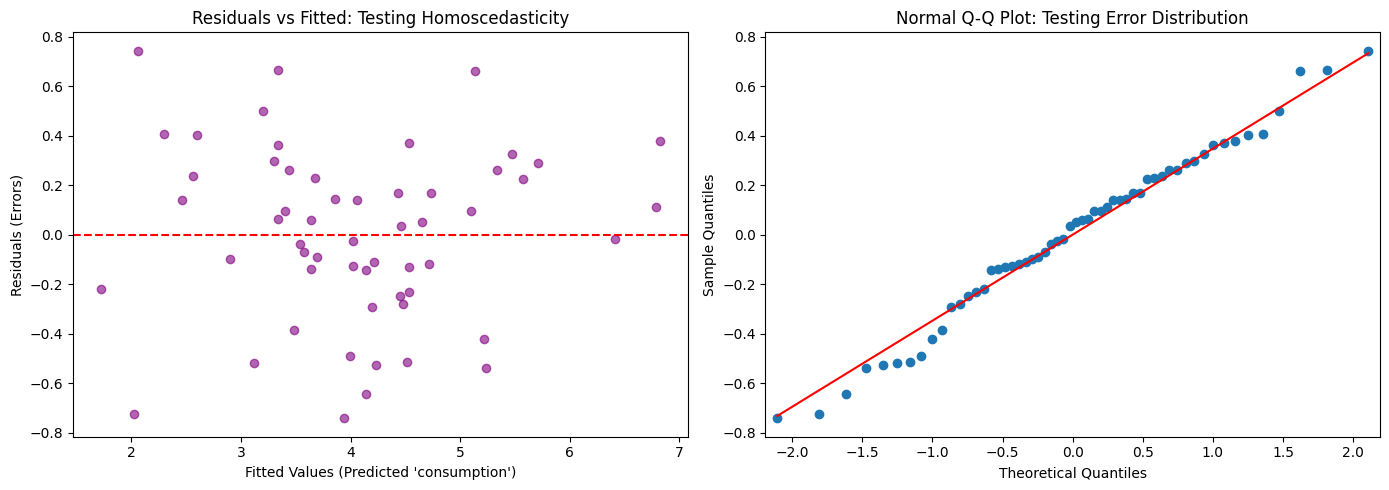

In [108]:
import statsmodels.api as sm
import scipy.stats as stats

# 1. Extract residuals and fitted values
residuals = regr.resid
fitted_vals = regr.fittedvalues

# 2. Create a Diagnostic Figure
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Residuals vs Fitted (Independence & Homoscedasticity)
ax[0].scatter(fitted_vals, residuals, color='purple', alpha=0.6)
ax[0].axhline(y=0, color='red', linestyle='--')
ax[0].set_xlabel("Fitted Values (Predicted 'consumption')")
ax[0].set_ylabel("Residuals (Errors)")
ax[0].set_title("Residuals vs Fitted: Testing Homoscedasticity")

# Plot B: Q-Q Plot (Testing Normality)
sm.qqplot(residuals, line='s', ax=ax[1])
ax[1].set_title("Normal Q-Q Plot: Testing Error Distribution")

plt.tight_layout()
plt.show()

- **The "Cloud"**: In the first plot, our points look like a random data cloud. There is no clear pattern (like a curve) or change in spread (funnel). This confirms Homoscedasticity and that our linear functional form is correct.
- **The "Line"**: In the Q-Q plot, the points hug the red line closely for the most part. This confirms the Normality assumption we saw earlier with the Jarque-Bera test.


### 4. The Interaction Model (Non-Additive Geometry).
Mathematically, we are moving from a simple sum of features to a Product Space. We introduce a term that is the literal multiplication of the categorical dummy and the continuous temperature variable. This means we move from "Parallel Manifolds" to "Interactive Manifolds." This is a significant jump in geometric complexity.

In the additive model, we assumed that insulation has a constant benefit regardless of the weather. In the Interaction Model, we test the hypothesis that insulation changes the building's sensitivity to temperature.

#### 4.1. Fitting the Interaction Model
In R and Python (`statsmodels`), the `*` operator is a powerful shortcut. 
* Writing `quando * temp` is equivalent to `quando + temp + quando:temp`.
* It tells the model: "Give me the intercept shift AND the slope change."

**The Mathematical Equation:**
$$y = \beta_0 + \beta_1(Q) + \beta_2(T) + \beta_3(Q \times T) + \epsilon$$

* $\beta_1$: The difference in intercepts (Shift).
* $\beta_3$: The difference in slopes (Rotation). This is the **Interaction Coefficient**.

In [109]:
# The '*' operator automatically includes main effects and the interaction term
regr2 = smf.ols('cons ~ quando * temp', data=df1).fit()

print(regr2.summary())

                            OLS Regression Results                            
Dep. Variable:                   cons   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     222.3
Date:                Thu, 16 Apr 2026   Prob (F-statistic):           1.23e-29
Time:                        18:22:32   Log-Likelihood:                -14.100
No. Observations:                  56   AIC:                             36.20
Df Residuals:                      52   BIC:                             44.30
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                4.7238 

By allowing the lines to "tilt" (interact), we have uncovered a deeper physical truth about how insulation works. Let’s interpret this "Interactive Manifold" mathematically and statistically. In the Additive Model, we had one slope. Here, we have a **Reference Slope** and a **Slope Adjustment**.

* **Intercept ($\beta_0 = 4.7238$):** Expected consumption for **"dopo"** at $0^\circ C$.
* **`temp` ($\beta_2 = -0.2779$):** This is the slope **specifically for the "dopo" (insulated) group**. For every degree rise, consumption drops by $0.27$ units.
* **`quando[T.prima]:temp` ($\beta_3 = -0.1153$):** This is the **Interaction Effect**. It tells us how much *steeper* the slope was before insulation.
    * **The "Prima" Slope:** $(-0.2779) + (-0.1153) = \mathbf{-0.3932}$.
    * **Physical Interpretation:** Before insulation, the building was **more sensitive** to temperature changes. It lost heat faster. Insulation didn't just save a flat amount of fuel; it made the building more "thermally stable" (a flatter slope).

#### 4.2. Model Selection (Which one is "Best"?)
**Theory Hook:** We use the principle of **Parsimony** (Occam’s Razor). We want the simplest model that explains the data well. We compare them using two main tools:

1.  **The Partial F-Test (ANOVA):** We test the Null Hypothesis $H_0: \beta_3 = 0$. If we reject it, the interaction is necessary.
2.  **Information Criteria (AIC/BIC):**
    * **AIC (Akaike):** Focuses on predictive accuracy.
    * **BIC (Bayesian):** Penalizes complexity more harshly to find the "true" underlying model.
    * **Rule:** Lower is always better.

In [110]:
from statsmodels.stats.anova import anova_lm

# Perform the Partial F-test
# This checks if the 'Reduction in Residuals' from the old model to the new model is significant
anova_results = anova_lm(regr, regr2)
print("ANOVA F-test:\n", anova_results)

print(f"\nAdditive Model AIC: {regr.aic:.2f}")
print(f"Interaction Model AIC: {regr2.aic:.2f}")

# Decision Logic
if regr2.pvalues['quando[T.prima]:temp'] < 0.05:
    print("\nConclusion: The Interaction Model is significantly better. The lines are not parallel.")
else:
    print("\nConclusion: Stick to the Additive Model (Parsimony). Parallel lines are sufficient.")

ANOVA F-test:
    df_resid       ssr  df_diff   ss_diff          F    Pr(>F)
0      53.0  6.770382      0.0       NaN        NaN       NaN
1      52.0  5.425247      1.0  1.345135  12.892872  0.000731

Additive Model AIC: 46.60
Interaction Model AIC: 36.20

Conclusion: The Interaction Model is significantly better. The lines are not parallel.


You have three pieces of evidence that the Interaction Model is the superior mathematical representation:

**A. The Partial F-test (ANOVA)**
* **Result:** `Pr(>F) = 0.000731`.
* **Meaning:** This tests the Null Hypothesis $H_0: \beta_3 = 0$ (Parallel Lines). Since $p < 0.001$, we reject $H_0$. The reduction in the **Sum of Squared Residuals (SSR)** from $6.77$ to $5.42$ is far too large to be a coincidence.

**B. Information Criteria (AIC & BIC)**
* **Additive AIC:** 46.60
* **Interaction AIC:** 36.20
* **Rule of Thumb:** A drop in AIC of **$> 10$** is considered "overwhelming evidence" in favor of the more complex model. Even though we added a parameter, the massive increase in "Likelihood" (how well the model fits the data) justifies the complexity.

**C. R-squared ($R^2$)**
* **Jump:** $0.910 \to 0.928$.
* We are now explaining nearly **93%** of the variance in fuel consumption.


Notice that as we made the model more complex, the diagnostics shifted:

* **Durbin-Watson ($1.854$):** This is much closer to the ideal value of **2.0** than the $1.5$ we saw in the additive model. By accounting for the interaction, we’ve removed some of the "unexplained patterns" that were causing autocorrelation.
* **Omnibus ($p = 0.049$):** This is borderline. It suggests the residuals might have a slight non-normal "shiver." However, the **Jarque-Bera ($0.082$)** is still above $0.05$, so we can generally still trust our $p$-values.
* **Condition Number ($30.9$):** It hit the "danger zone" limit of 30. This is expected! When you multiply $X_1$ by $X_2$, the new feature is naturally correlated with its parents. In **Geometric Learning**, this is a sign of a "near-collinear" manifold.

#### 4.3. Mathematical Synthesis.
You can now write the two distinct "Physics Equations" for the building:

1.  **Insulated (Dopo):**
    $$\widehat{Cons} = 4.72 - 0.28 \cdot Temp$$
2.  **Uninsulated (Prima):**
    $$\widehat{Cons} = (4.72 + 2.13) + (-0.28 - 0.11) \cdot Temp = \mathbf{6.85 - 0.39 \cdot Temp}$$

### 5. Uncertainty & Projections (Intervals)
In a Hilbert Space, we found the "best" projection. However, our data is finite and noisy. Therefore, our projection is just an estimate. We must define a "safety buffer" around our prediction.

#### 1. The Mathematical Duality: Confidence vs. Prediction
This is a high-probability exam topic. You must distinguish between the uncertainty of the **mean** and the uncertainty of an **individual**.

**A. Confidence Interval (CI) - The "Mean"**
* **Question:** "What is the average fuel consumption for *all* weeks where the temperature is $10^\circ C$?"
* **Math:** It only accounts for the uncertainty in our estimate of $\beta$. As $n \to \infty$, the CI shrinks toward zero.
* **Variance:** $\sigma^2 [\mathbf{x}_0^T (X^T X)^{-1} \mathbf{x}_0]$

**B. Prediction Interval (PI) - The "Individual"**
* **Question:** "What will be the fuel consumption for *next* week if the temperature is $10^\circ C$?"
* **Math:** It accounts for the uncertainty of the line **PLUS** the inherent random noise ($\epsilon$) of that specific week. Even with infinite data, the PI never shrinks to zero; it is bounded by $\sigma$.
* **Variance:** $\sigma^2 [1 + \mathbf{x}_0^T (X^T X)^{-1} \mathbf{x}_0]$



#### 5.1. Generating the Intervals in Python
`statsmodels` provides the `get_prediction` method, which is much more robust than manual calculation because it correctly handles the $(X^T X)^{-1}$ matrix and the student-t distributions.

In [111]:
import numpy as np
import pandas as pd

In [112]:
# We create a range of temperatures to 'predict' over
temp_range = np.linspace(df1.temp.min(), df1.temp.max(), 100)

# We must create a new dataframe for predictions to feed into the model
# Let's look specifically at the 'dopo' (insulated) scenario first
new_data_dopo = pd.DataFrame({'temp': temp_range, 'quando': 'dopo'})

# Get predictions
pred_obj = regr2.get_prediction(new_data_dopo)
pred_summary = pred_obj.summary_frame(alpha=0.05) # 95% interval

# pred_summary now contains:
# 'mean' (the line), 'mean_ci_lower/upper' (CI), and 'obs_ci_lower/upper' (PI)
print(pred_summary.head())

       mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  4.946198  0.134298       4.676708       5.215687      4.244250   
1  4.915316  0.132015       4.650409       5.180223      4.215115   
2  4.884434  0.129741       4.624090       5.144779      4.185947   
3  4.853553  0.127477       4.597751       5.109355      4.156746   
4  4.822671  0.125225       4.571389       5.073953      4.127511   

   obs_ci_upper  
0      5.648145  
1      5.615517  
2      5.582921  
3      5.550360  
4      5.517831  


##### 5.2. The GGPlot (The Synthesis)
In the Professor's R code, he used `ggplot2` to layer these intervals. We will do the same in Python using `matplotlib`'s `fill_between`. This plot is the **visual proof** of our entire study.

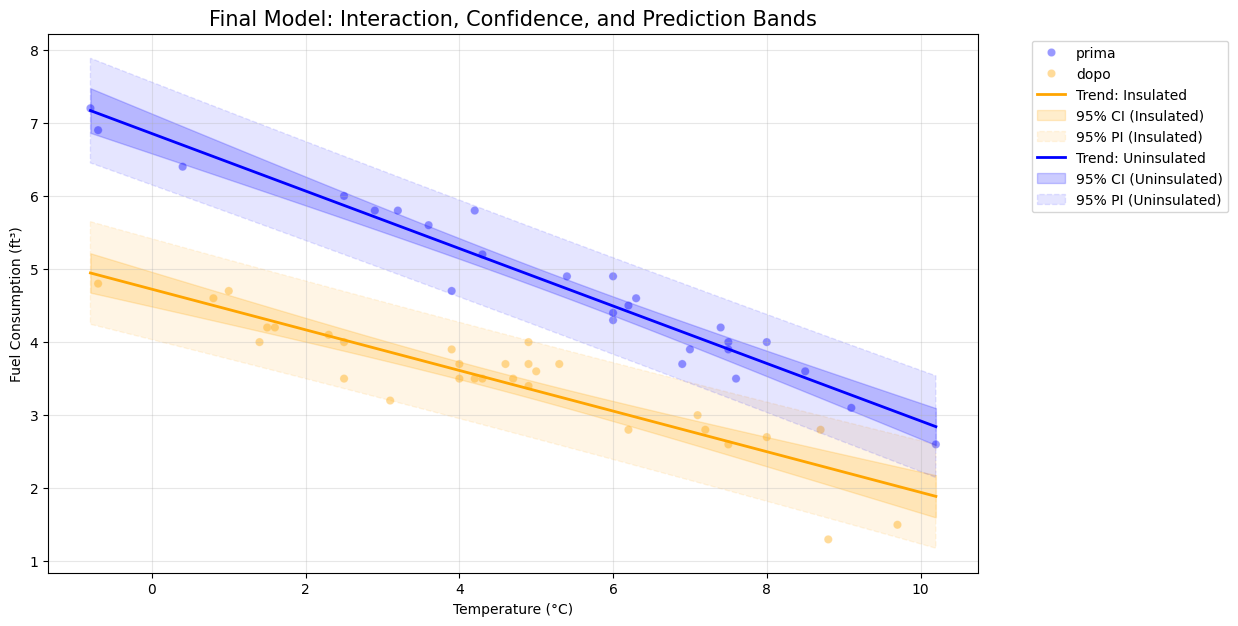

In [113]:
plt.figure(figsize=(12, 7))

# 1. Plot the raw data
sns.scatterplot(data=df1, x='temp', y='cons', hue='quando', palette=['blue', 'orange'], alpha=0.4)

# 2. Function to plot bands for a specific group
def plot_model_bands(model, quando_val, color, label):
    X_new = pd.DataFrame({'temp': temp_range, 'quando': quando_val})
    preds = model.get_prediction(X_new).summary_frame(alpha=0.05)
    # Plot the regression line
    plt.plot(temp_range, preds['mean'], color=color, lw=2, label=f'Trend: {label}')
    # Plot Confidence Interval (narrower)
    plt.fill_between(temp_range, preds['mean_ci_lower'], preds['mean_ci_upper'], 
                     color=color, alpha=0.2, label=f'95% CI ({label})')
    # Plot Prediction Interval (wider)
    plt.fill_between(temp_range, preds['obs_ci_lower'], preds['obs_ci_upper'], 
                     color=color, alpha=0.1, linestyle='--', label=f'95% PI ({label})')

# Execute for both scenarios
plot_model_bands(regr2, 'dopo', 'orange', 'Insulated')
plot_model_bands(regr2, 'prima', 'blue', 'Uninsulated')

plt.title("Final Model: Interaction, Confidence, and Prediction Bands", fontsize=15)
plt.xlabel("Temperature (°C)")
plt.ylabel("Fuel Consumption (ft³)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

As you look at the final plot, notice two things:
1.  **The Divergence:** The blue line (Prima) is steeper than the orange line (Dopo). This is the **Interaction** we proved in Part 4.
2.  **The Width:** Notice how the shaded areas (PI) encompass almost all the data points, while the darker ribbons (CI) only surround the line itself. 

**Wait! One last nuance:**
Look at the width of the bands at the edges of the temperature range versus the middle. Are they wider at the ends?
* **Why?** The term $\mathbf{x}_0^T (X^T X)^{-1} \mathbf{x}_0$ is minimized when $\mathbf{x}_0$ is at the mean of the data. As you move toward extreme temperatures (the edges), our uncertainty increases. This is the **Curse of Extrapolation**—the further you get from your data's "center of mass," the less the Hilbert space can guarantee your projection's accuracy.